In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df =pd.read_csv("data/iris.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
df.nunique()

sepal_length    35
sepal_width     23
petal_length    43
petal_width     22
species          3
dtype: int64

In [6]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [7]:
df["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

<Axes: xlabel='species', ylabel='count'>

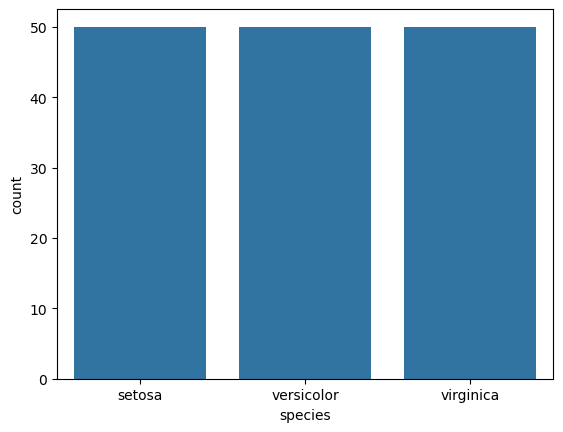

In [8]:
sns.countplot(x=df["species"])

<Axes: xlabel='petal_length', ylabel='petal_width'>

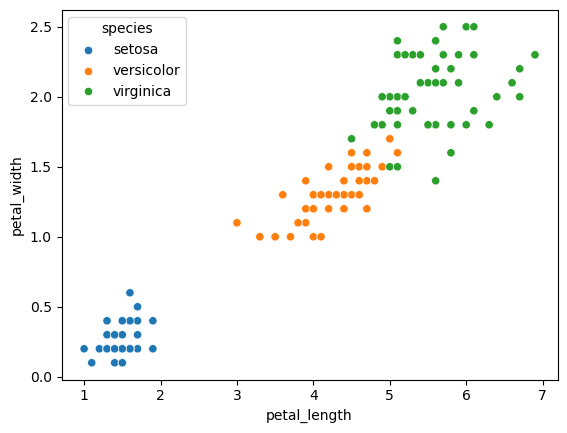

In [9]:
sns.scatterplot(x=df["petal_length"],y=df["petal_width"],data=df,hue=df["species"])

In [10]:

df.corr(numeric_only=True)

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.109369,0.871754,0.817954
sepal_width,-0.109369,1.000000,-0.420516,-0.356544
petal_length,0.871754,-0.420516,1.000000,0.962757
petal_width,0.817954,-0.356544,0.962757,1.000000


<Axes: >

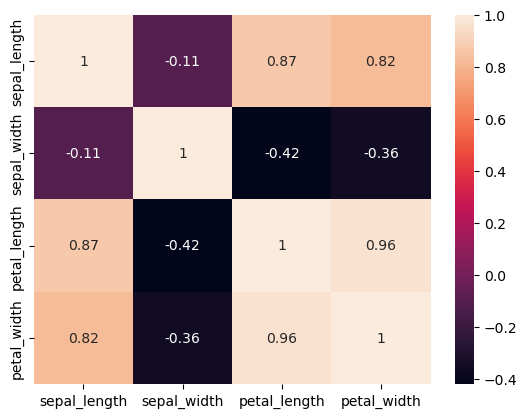

In [11]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [12]:
X=df.drop("species",axis=1)
y=df["species"]

In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=25,random_state=101)

In [14]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(X_train)
scaled_X_train=scaler.transform(X_train)
scaled_X_test=scaler.transform(X_test)


In [15]:
from sklearn.linear_model import LogisticRegression


In [16]:
from sklearn.model_selection import GridSearchCV

In [24]:
from sklearn.multiclass import OneVsRestClassifier
log_model=LogisticRegression(solver='saga',max_iter=5000)
model=OneVsRestClassifier(log_model)

In [30]:
l1_ratio=np.linspace(0.1, 0.9, 9)
C=np.logspace(-2, 4, 15)
param_grid = [
    {
        'estimator__penalty': ['l1'],
        'estimator__solver': ['saga'],
        'estimator__C': C,  
    },
    {
        'estimator__penalty': ['l2'],
        'estimator__solver': ['lbfgs'],  
        'estimator__C': C,
    },
    {
        'estimator__penalty': ['elasticnet'],
        'estimator__solver': ['saga'],
        'estimator__C': C,
        'estimator__l1_ratio': np.linspace(0.1, 0.9, 9),
    }
]

In [31]:
grid_model=GridSearchCV(model,param_grid=param_grid)

In [32]:
grid_model.fit(scaled_X_train,y_train);

In [42]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,ConfusionMatrixDisplay

In [36]:
grid_model.best_params_

{'estimator__C': np.float64(26.826957952797247),
 'estimator__penalty': 'l1',
 'estimator__solver': 'saga'}

In [38]:
y_pred=grid_model.predict(scaled_X_test)

In [39]:
y_pred

array(['setosa', 'setosa', 'setosa', 'virginica', 'versicolor',
       'virginica', 'versicolor', 'versicolor', 'virginica', 'setosa',
       'virginica', 'setosa', 'setosa', 'virginica', 'virginica',
       'versicolor', 'versicolor', 'versicolor', 'setosa', 'versicolor',
       'versicolor', 'setosa', 'versicolor', 'versicolor', 'versicolor'],
      dtype='<U10')

In [40]:
accuracy_score(y_test,y_pred)

0.96

In [43]:
con_mat=confusion_matrix(y_test,y_pred)

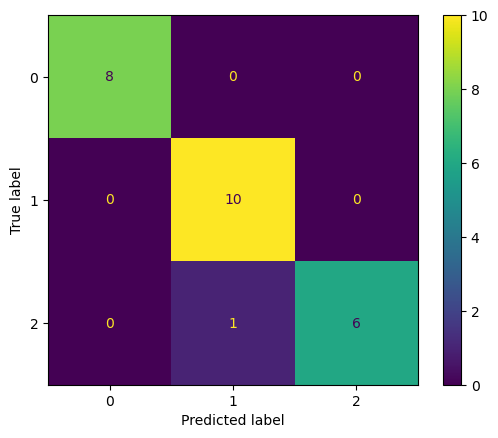

In [45]:
ConfusionMatrixDisplay(con_mat).plot()

In [47]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         8
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.86      0.92         7

    accuracy                           0.96        25
   macro avg       0.97      0.95      0.96        25
weighted avg       0.96      0.96      0.96        25

